In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new.h5ad')

In [3]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation_new.h5ad')

In [4]:
adata_t.obs['original_index'] = adata_t.obs_names
lst = adata_t.obs['original_index'].astype(str).str.split('-')
adata_t.obs['original_index_split'] = list(zip(*lst))[0]
adata_t.obs_names = adata_t.obs['sample'].astype(str) + '_' + adata_t.obs['original_index_split']

In [5]:
temp_index = pd.DataFrame(adata_t.obs['original_index']).reset_index()
temp_index.index = temp_index['original_index']
index_dict = temp_index.to_dict()['index']

In [6]:
adata_t.obs_names

Index(['E30_F1_AAACCTGTCTCGGACG', 'E30_F1_AAACGGGAGCCCAGCT',
       'E30_F1_AAACGGGCAACCGCCA', 'E30_F1_AAACGGGCACTTCGAA',
       'E30_F1_AAACGGGGTCTCAACA', 'E30_F1_AAAGATGCAAGTTAAG',
       'E30_F1_AAAGATGGTACCGGCT', 'E30_F1_AAAGATGTCCACGACG',
       'E30_F1_AAAGCAAAGGCAGGTT', 'E30_F1_AAAGCAACAATAACGA',
       ...
       'E43_B_DN_TTTACTGTCAACACGT', 'E43_B_DN_TTTATGCGTCGCATAT',
       'E43_B_DN_TTTCCTCTCCCTCAGT', 'E43_B_DN_TTTGCGCAGCGCCTCA',
       'E43_B_DN_TTTGCGCAGCTGCGAA', 'E43_B_DN_TTTGCGCGTTGAGTTC',
       'E43_B_DN_TTTGTCAAGTGCGTGA', 'E43_B_DN_TTTGTCACAAGCGAGT',
       'E43_B_DN_TTTGTCACAGCGTTCG', 'E43_B_DN_TTTGTCAGTACCCAAT'],
      dtype='object', length=138523)

In [7]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [8]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_9826/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [9]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [10]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# Shared clones above threshold

In [11]:
spectra_tr_score = pd.read_csv(
    '/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tcells_UCell_TRsig_scored.csv')
del spectra_tr_score['Unnamed: 0']
spectra_tr_score.index = spectra_tr_score['V2']
del spectra_tr_score['V2']
spectra_tr_score.columns = ['TR_Score']

In [12]:
adata.obs['spectra_tr_score'] = spectra_tr_score['TR_Score']

In [13]:
adata.obs['spectra_tr_score_binary'] = (
    adata.obs['spectra_tr_score'] > 0.285).map({True : 'TR',
                                             False : 'Not TR'})

In [14]:
tr_clonotype_patient = adata[
    adata.obs['spectra_tr_score_binary'] == 'TR'].obs['clonotype_patient'].unique().tolist()
tr_barcodes = pd.DataFrame(adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs_names)
tr_barcodes['identity'] = ['TR'] * len(tr_barcodes)
tr_barcodes.index = tr_barcodes['sample_index']
adata.obs['TR_cell'] = tr_barcodes['identity']

In [15]:
cells_per_patient = pd.DataFrame(adata.obs['sample_x'].value_counts())
cells_per_patient.columns = ['num_cells']

In [16]:
patient_progression = adata.obs[['sample_x','progression']].drop_duplicates()
patient_progression.index = patient_progression['sample_x']

In [17]:
tr_cells_per_sample = adata[~(adata.obs['TR_cell'].isnull())
    ].obs[['sample_x']].value_counts().reset_index()
tr_cells_per_sample.index = tr_cells_per_sample['sample_x']
tr_cells_per_sample = pd.concat([tr_cells_per_sample, cells_per_patient], axis=1)
del tr_cells_per_sample['sample_x']
tr_cells_per_sample = tr_cells_per_sample.reset_index()
tr_cells_per_sample = tr_cells_per_sample.fillna(0)
tr_cells_per_sample['timepoint'] = [i.split('_')[1] for i in tr_cells_per_sample['index']]
tr_cells_per_sample['progression'] = tr_cells_per_sample['index'].map(patient_progression['progression'].to_dict())
tr_cells_per_sample['prop_tr_cells'] = tr_cells_per_sample[0] / tr_cells_per_sample['num_cells']
tr_cells_per_sample['timepoint_progression'] = tr_cells_per_sample['progression'].astype(str) + ' ' + tr_cells_per_sample['timepoint'].astype(str)

In [18]:
adata_t.obs['spectra_tr_score'] = adata.obs['spectra_tr_score']

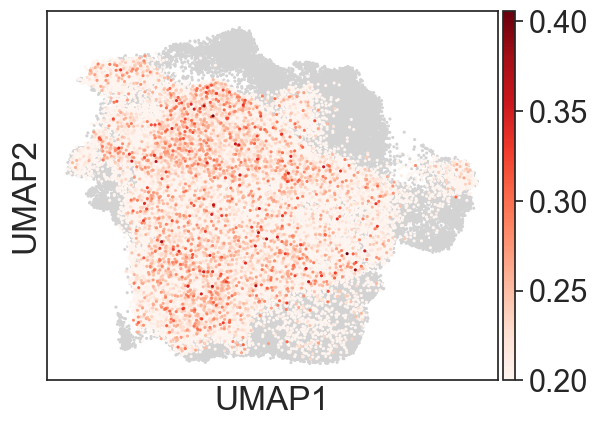

In [19]:
sns.set(font_scale=2)
sns.set_style('white')
sc.pl.umap(adata_t,color=['spectra_tr_score'],size=20,vmin=0.2,cmap='Reds',title='')

In [20]:
adata_t.obs['spectra_tr_score']

E30_F1_AAACCTGTCTCGGACG           NaN
E30_F1_AAACGGGAGCCCAGCT           NaN
E30_F1_AAACGGGCAACCGCCA      0.040507
E30_F1_AAACGGGCACTTCGAA           NaN
E30_F1_AAACGGGGTCTCAACA           NaN
                               ...   
E43_B_DN_TTTGCGCGTTGAGTTC         NaN
E43_B_DN_TTTGTCAAGTGCGTGA         NaN
E43_B_DN_TTTGTCACAAGCGAGT         NaN
E43_B_DN_TTTGTCACAGCGTTCG         NaN
E43_B_DN_TTTGTCAGTACCCAAT         NaN
Name: spectra_tr_score, Length: 138523, dtype: float64

In [21]:
adata_t

AnnData object with n_obs × n_vars = 138523 × 33275
    obs: 'sample', 'patient', 'timepoint', 'normal', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet', 'leiden_res0_5_log1p_norm', 'annot_1st', 'annot_2nd', 'annot_3rd', 'original_index', 'original_index_split', 'spectra_tr_score'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'annot_2nd_colors', 'annot_3rd_colors', 'dendrogram_leiden_res0_5_log1p_norm', 'leiden', 'leiden_res0_5_log1p_norm_colors', 'log1p_norm_pca', 'normal_colors', 'patient_colors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'log1p_norm_pca'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'log1p_norm_pca_connectivities', 'log1p_norm_pca_distances'

In [22]:
adata

AnnData object with n_obs × n_vars = 43777 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_

In [23]:
adata_t

AnnData object with n_obs × n_vars = 138523 × 33275
    obs: 'sample', 'patient', 'timepoint', 'normal', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet', 'leiden_res0_5_log1p_norm', 'annot_1st', 'annot_2nd', 'annot_3rd', 'original_index', 'original_index_split', 'spectra_tr_score'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'annot_2nd_colors', 'annot_3rd_colors', 'dendrogram_leiden_res0_5_log1p_norm', 'leiden', 'leiden_res0_5_log1p_norm_colors', 'log1p_norm_pca', 'normal_colors', 'patient_colors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'log1p_norm_pca'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'log1p_norm_pca_connectivities', 'log1p_norm_pca_distances'